In [12]:
# MÓDULOS E IMPORTAÇÕES
import kagglehub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns       # Referência de estudo: https://www.dannidanliu.com/introduction-to-s/

from datetime import date, datetime

In [13]:
# Loading data
file = 'air traffic.csv'
df_original = pd.read_csv(f'data\{file}')

In [14]:
# Processing data
df = df_original.copy()

df = df[['Year', 'Month', 'Flt']]
df['date'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))
df['flights'] = df['Flt'].str.replace(',', '').astype('Int32')

df = df.drop(columns=['Year', 'Month', 'Flt'])
df = df.sort_values('date')

# Linear Regression Models

In [15]:
def process_historical_data(df, K):

    X = pd.DataFrame()
    
    for i in range(1, K + 1):
        v = df['flights'].rename(f'x_{i}').shift(i)
        X = pd.concat([X, v], axis=1)

    y = df.copy()
    y.rename(columns={'flights': 'y'}, inplace=True)

    df_processed = pd.concat([y, X], axis=1).dropna().reset_index(drop=True)  # for dropping redundant rows with null values

    return df_processed

In [16]:
df_validation_metrics = pd.DataFrame()

for K in range(1, 24 + 1):

    df_processed = process_historical_data(df, K)

    # Solicitação do item c)
    df_train = df_processed[df_processed['date'] <= '2019-12-01']
    df_valid = df_processed[('2019-12-01' < df_processed['date']) & (df_processed['date'] <= '2021-12-01')]
    df_test = df_processed['2021-12-01' < df_processed['date']]

    X_train = df_train.drop(columns=['date','y'])
    y_train = df_train['y']

    X_valid = df_valid.drop(columns=['date','y'])
    y_valid = df_valid['y']

    from sklearn.linear_model import LinearRegression

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = pd.Series(model.predict(X_valid))

    df_result = pd.concat(
    [y_valid.rename('y').reset_index(drop=True), 
        y_pred.rename('ŷ = f(x,θ)').astype(int).reset_index(drop=True)],  # deliberadamente converti a previsão para um número inteiro. 
    axis = 1
    )

    df_result.insert(0, 'date', df_valid['date'].reset_index(drop=True))

    df_result['ϵ = y - ŷ'] = df_result['y'] - df_result['ŷ = f(x,θ)']
    df_result['|ϵ|'] = abs(df_result['ϵ = y - ŷ'])
    df_result['ϵ²'] = df_result['ϵ = y - ŷ']*df_result['ϵ = y - ŷ']
    df_result['ϵr = 1 - ŷ/y'] = df_result['ϵ = y - ŷ']/df_result['y']
    df_result['|er|'] = abs(df_result['ϵr = 1 - ŷ/y'])
    df_result['100% × |er|'] = df_result['|er|'].map('{:.2%}'.format)

    # display(df_result.head())
    # display(df_result.drop(columns='date').describe())

    MSE = df_result['ϵ²'].mean()
    RMSE = MSE**(1/2)
    MAPE = df_result['|er|'].mean()*100

    # Determination Coefficient R²

    μ = df_result['y'].mean()
    var = (μ - df_result['y'])**2
    σ2 = var.mean()

    R2 = 1 - MSE/σ2

    validation_dict = {'K': K, 'RMSE': RMSE, 'MAPE': MAPE, 'R2': R2}
    df_validation = pd.DataFrame([validation_dict])
    #display(df_validation)

    df_validation_metrics = pd.concat([df_validation_metrics, df_validation], axis=0)

In [17]:
df_viz_validation = df_validation_metrics.style.format({'RMSE': '{:.0f}', 'MAPE': '{:.3f}%', 'R2': '{:.4f}'})
df_viz_validation

,K,RMSE,MAPE,R2
0,1,121830,22.442%,0.3967
0,2,122001,21.657%,0.3950
0,3,121800,21.709%,0.3970
0,4,123708,22.026%,0.3780
0,5,121371,21.439%,0.4012
0,6,123438,22.351%,0.3807
0,7,128024,21.661%,0.3338
0,8,148590,26.312%,0.1026
0,9,182082,35.818%,-0.3476
0,10,176522,34.015%,-0.2665


<Axes: xlabel='K', ylabel='R2'>

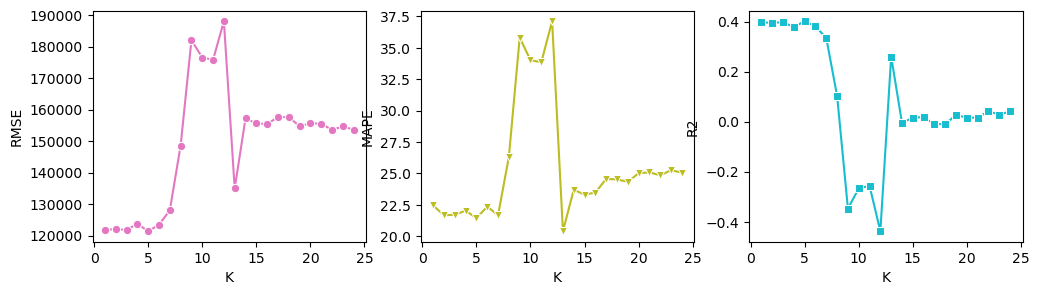

In [18]:
fig, (ax_1, ax_2, ax_3) = plt.subplots(nrows=1, ncols=3, sharex=True, figsize=(12, 3))

sns.lineplot(x=df_validation_metrics['K'], y=df_validation_metrics['RMSE'], ax=ax_1, color = 'tab:pink', marker = 'o')
sns.lineplot(x=df_validation_metrics['K'], y=df_validation_metrics['MAPE'], ax=ax_2, color = 'tab:olive', marker = 'v')
sns.lineplot(x=df_validation_metrics['K'], y=df_validation_metrics['R2'],  ax=ax_3, color = 'tab:cyan', marker = 's')
#plt.legend(loc='best')

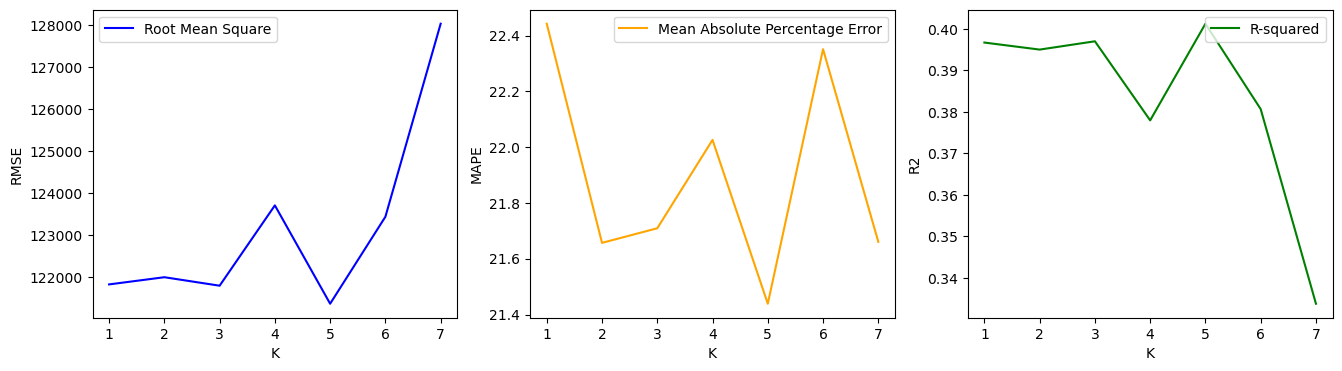

In [19]:
df_validation_metrics = df_validation_metrics.copy()

df_validation_metrics = df_validation_metrics[(df_validation_metrics['K'] > 0) & (df_validation_metrics['K'] < 8)]

fig, (ax_1, ax_2, ax_3) = plt.subplots(nrows=1, ncols=3, sharex=True, figsize=(16, 4))

sns.lineplot(x=df_validation_metrics['K'], y=df_validation_metrics['RMSE'], color='blue', label='Root Mean Square', ax=ax_1)
sns.lineplot(x=df_validation_metrics['K'], y=df_validation_metrics['MAPE'], color='orange', label='Mean Absolute Percentage Error', ax=ax_2)
sns.lineplot(x=df_validation_metrics['K'], y=df_validation_metrics['R2'], color='green', label='R-squared', ax=ax_3)
plt.legend(loc='upper right')

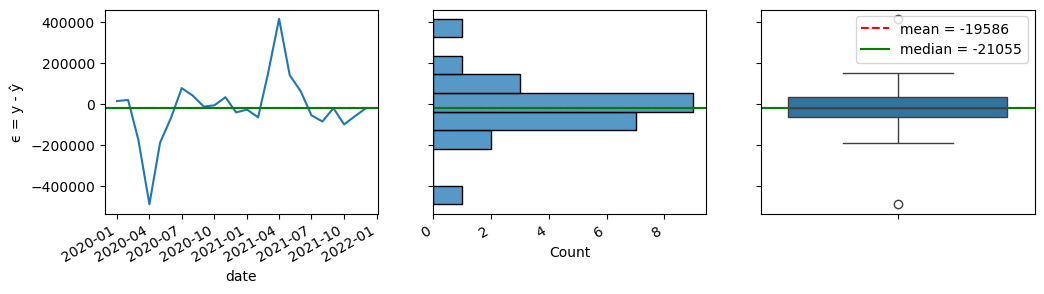

In [20]:
fig, (ax_plot, ax_hist, ax_box) = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 3))

mean = df_result['ϵ = y - ŷ'].mean()
median = df_result['ϵ = y - ŷ'].median()

sns.lineplot(x = df_result['date'], y = df_result['ϵ = y - ŷ'], ax=ax_plot)
ax_plot.axhline(mean, color='r', linestyle='--')
ax_plot.axhline(median, color='g', linestyle='-')

sns.histplot(y = df_result['ϵ = y - ŷ'], ax=ax_hist)
ax_hist.axhline(mean, color='r', linestyle='--', label='mean')
ax_hist.axhline(median, color='g', linestyle='-', label='median')

sns.boxplot(df_result['ϵ = y - ŷ'], ax=ax_box)
ax_box.axhline(mean, color='r', linestyle='--', label=f'mean = {mean:.0f}')
ax_box.axhline(median, color='g', linestyle='-', label=f'median = {median:.0f}')

fig.autofmt_xdate()
plt.legend(loc='upper right')